In [2]:
pip install vaderSentiment

  Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl.metadata (572 bytes)
Using cached vaderSentiment-3.3.2-py2.py3-none-any.whl (125 kB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ================================================
# Phase 5 — Sentiment Analysis of Customer Feedback
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')


In [7]:
# ================================================
# Step 1 — Load and Pre-process Feedback Data
# ================================================

# Load feedback data — no header, just reviews
feedback = pd.read_csv('../data/Online Retail Customer Feedback.csv',
                       header=None, names=['Review'])

# Remove empty rows
feedback = feedback.dropna()
feedback = feedback[feedback['Review'].str.strip() != '']
feedback = feedback.reset_index(drop=True)

print("Feedback data loaded!")
print("Total reviews:", len(feedback))
print("\nFirst 5 reviews:")
print(feedback.head())

Feedback data loaded!
Total reviews: 965

First 5 reviews:
                                              Review
0  customer support was slightly disappointing, b...
1  the experience was decent, and the final bille...
2                                Superr 10 out of 10
3                                    wow nice option
4  i found the buying process to be quite good, t...


In [8]:
# ================================================
# Step 2 — Perform Sentiment Analysis using VADER
# ================================================

analyser = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = analyser.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive', compound
    elif compound <= -0.05:
        return 'Negative', compound
    else:
        return 'Neutral', compound

# Apply to all reviews
feedback['Sentiment'], feedback['Score'] = zip(
    *feedback['Review'].apply(get_sentiment)
)

print("=== Sentiment Analysis Complete ===")
print(feedback[['Review', 'Sentiment', 'Score']].head(10))
print("\nSentiment distribution:")
print(feedback['Sentiment'].value_counts())
print(f"\nAverage sentiment score: {feedback['Score'].mean():.3f}")

=== Sentiment Analysis Complete ===
                                              Review Sentiment   Score
0  customer support was slightly disappointing, b...   Neutral -0.0267
1  the experience was decent, and the final bille...  Positive  0.4588
2                                Superr 10 out of 10   Neutral  0.0000
3                                    wow nice option  Positive  0.7650
4  i found the buying process to be quite good, t...  Positive  0.2467
5  , using the app was inconsistent, but billing ...   Neutral  0.0000
6  the ordering experience felt a bit confusing, ...  Negative -0.1531
7  using the app was decent, but communication fr...  Positive  0.8126
8  From my experience, the checkout process seeme...  Negative -0.1786
9                           The experience was good   Positive  0.4404

Sentiment distribution:
Sentiment
Positive    610
Negative    236
Neutral     119
Name: count, dtype: int64

Average sentiment score: 0.234


=== Sentiment Summary Table ===
Sentiment    Count    Percentage
-----------------------------------
Positive     610      63.2%
Neutral       119      12.3%
Negative     236      24.5%
Total           965      100.0%

Average score: 0.234


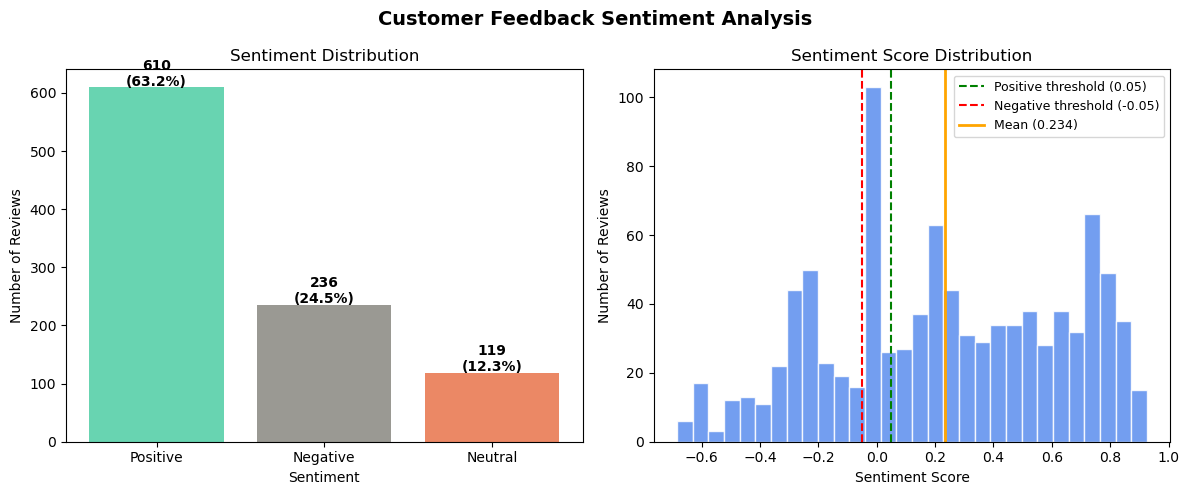

✅ Charts saved!


In [9]:
# ================================================
# Step 3 — Summarise with Tables and Charts
# ================================================

# Summary table
total    = len(feedback)
positive = len(feedback[feedback['Sentiment'] == 'Positive'])
neutral  = len(feedback[feedback['Sentiment'] == 'Neutral'])
negative = len(feedback[feedback['Sentiment'] == 'Negative'])

print("=== Sentiment Summary Table ===")
print(f"{'Sentiment':<12} {'Count':<8} {'Percentage'}")
print("-" * 35)
print(f"{'Positive':<12} {positive:<8} {positive/total*100:.1f}%")
print(f"{'Neutral':<12}  {neutral:<8} {neutral/total*100:.1f}%")
print(f"{'Negative':<12} {negative:<8} {negative/total*100:.1f}%")
print(f"{'Total':<12}    {total:<8} 100.0%")
print(f"\nAverage score: {feedback['Score'].mean():.3f}")

# Charts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#4ecda4', '#888780', '#e8734a']
sentiment_counts = feedback['Sentiment'].value_counts()
axes[0].bar(sentiment_counts.index,
            sentiment_counts.values,
            color=colors, alpha=0.85)
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(sentiment_counts.values):
    pct = v/total*100
    axes[0].text(i, v + 2, f'{v}\n({pct:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

# Score distribution
axes[1].hist(feedback['Score'], bins=30,
             color='#5b8dee', alpha=0.85, edgecolor='white')
axes[1].axvline(x=0.05,  color='green', linestyle='--',
                label='Positive threshold (0.05)')
axes[1].axvline(x=-0.05, color='red',   linestyle='--',
                label='Negative threshold (-0.05)')
axes[1].axvline(x=feedback['Score'].mean(), color='orange',
                linestyle='-', linewidth=2,
                label=f'Mean ({feedback["Score"].mean():.3f})')
axes[1].set_title('Sentiment Score Distribution')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend(fontsize=9)

plt.suptitle('Customer Feedback Sentiment Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/sentiment_distribution.png', dpi=150)
plt.show()
print("✅ Charts saved!")

=== Most Common Positive Keywords ===
  good                 → 70 reviews
  easy                 → 57 reviews
  happy                → 2 reviews
  fast                 → 2 reviews
  satisfied            → 2 reviews
  great                → 1 reviews
  recommend            → 1 reviews
  quality              → 1 reviews
  helpful              → 1 reviews

=== Most Common Negative Keywords ===
  slow                 → 103 reviews
  issue                → 63 reviews
  disappointing        → 60 reviews
  refund               → 56 reviews
  problem              → 1 reviews


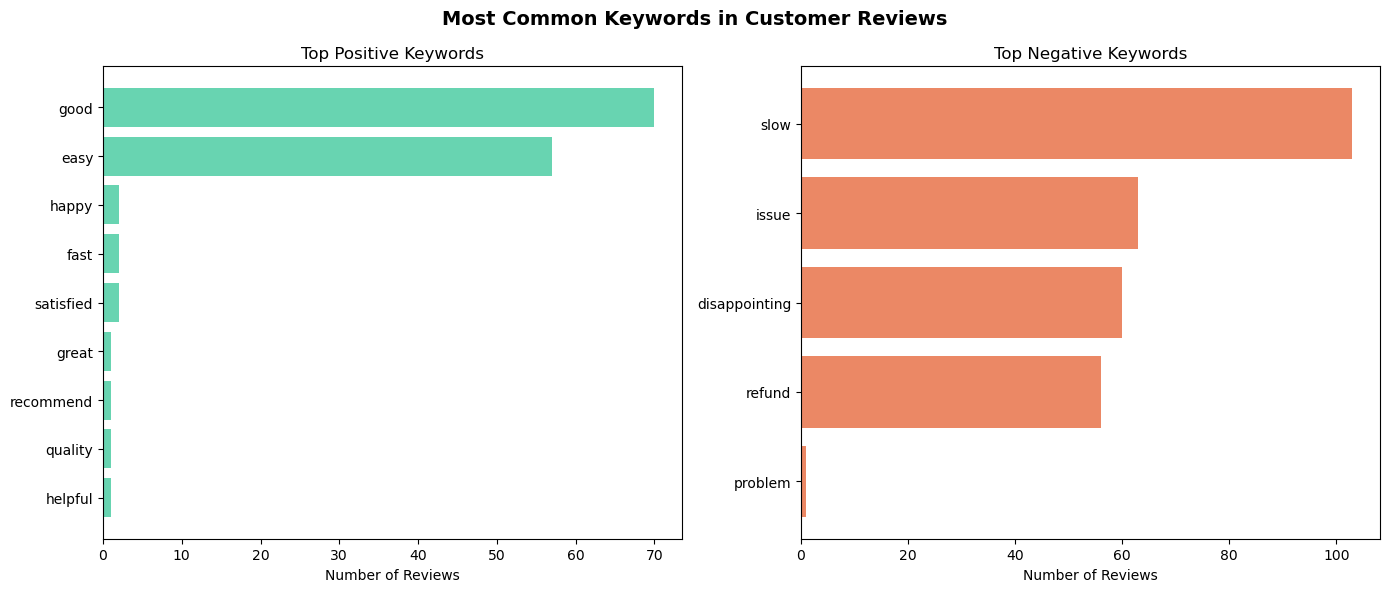

In [10]:
# ================================================
# Step 4 — Find Common Positive and Negative Keywords
# ================================================

positive_keywords = ['great', 'excellent', 'amazing', 'love',
                     'happy', 'fast', 'good', 'recommend',
                     'quality', 'perfect', 'wonderful', 'best',
                     'easy', 'helpful', 'friendly', 'satisfied']

negative_keywords = ['damaged', 'disappointed', 'terrible', 'wrong',
                     'broken', 'waiting', 'poor', 'refund', 'late',
                     'slow', 'bad', 'awful', 'horrible', 'problem',
                     'issue', 'worst', 'never', 'disappointing']

def count_keywords(reviews, keywords):
    counts = {}
    for keyword in keywords:
        count = sum(1 for review in reviews
                   if keyword.lower() in str(review).lower())
        if count > 0:
            counts[keyword] = count
    return dict(sorted(counts.items(),
                key=lambda x: x[1], reverse=True))

pos_counts = count_keywords(feedback['Review'], positive_keywords)
neg_counts = count_keywords(feedback['Review'], negative_keywords)

print("=== Most Common Positive Keywords ===")
for word, count in pos_counts.items():
    print(f"  {word:<20} → {count} reviews")

print("\n=== Most Common Negative Keywords ===")
for word, count in neg_counts.items():
    print(f"  {word:<20} → {count} reviews")

# Plot keywords
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if pos_counts:
    top_pos = dict(list(pos_counts.items())[:10])
    axes[0].barh(list(top_pos.keys())[::-1],
                 list(top_pos.values())[::-1],
                 color='#4ecda4', alpha=0.85)
    axes[0].set_title('Top Positive Keywords')
    axes[0].set_xlabel('Number of Reviews')

if neg_counts:
    top_neg = dict(list(neg_counts.items())[:10])
    axes[1].barh(list(top_neg.keys())[::-1],
                 list(top_neg.values())[::-1],
                 color='#e8734a', alpha=0.85)
    axes[1].set_title('Top Negative Keywords')
    axes[1].set_xlabel('Number of Reviews')

plt.suptitle('Most Common Keywords in Customer Reviews',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/sentiment_keywords.png', dpi=150)
plt.show()

In [12]:
# ================================================
# Step 5 — Business Insights
# ================================================

print("=== Business Insights ===\n")
print(f"Total reviews analysed: {total}")
print(f"Overall sentiment:      {'Positive' if feedback['Score'].mean() > 0 else 'Negative'}")
print(f"Average score:          {feedback['Score'].mean():.3f}")
print()

if positive > negative:
    print("✅ More customers are HAPPY than unhappy!")
else:
    print("⚠️  More customers are UNHAPPY than happy!")

print()
print("Top positive themes:")
for word, count in list(pos_counts.items())[:3]:
    print(f"  → {word} mentioned in {count} reviews")

print()
print("Top negative themes:")
for word, count in list(neg_counts.items())[:3]:
    print(f"  → {word} mentioned in {count} reviews")

print()
print("=== Recommended Actions ===")
print("1. Investigate most common complaints")
print("2. Highlight positive themes in marketing")
print("3. Monitor sentiment score monthly")
print("4. Follow up with negative sentiment customers")

=== Business Insights ===

Total reviews analysed: 965
Overall sentiment:      Positive
Average score:          0.234

✅ More customers are HAPPY than unhappy!

Top positive themes:
  → good mentioned in 70 reviews
  → easy mentioned in 57 reviews
  → happy mentioned in 2 reviews

Top negative themes:
  → slow mentioned in 103 reviews
  → issue mentioned in 63 reviews
  → disappointing mentioned in 60 reviews

=== Recommended Actions ===
1. Investigate most common complaints
2. Highlight positive themes in marketing
3. Monitor sentiment score monthly
4. Follow up with negative sentiment customers
